<a href="https://colab.research.google.com/github/hwasun-zip/rfm-customer-segmentation/blob/main/rfm_customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    !apt-get -qq install fonts-nanum
    from google.colab import drive; drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/retail_data"
except Exception:
    DATA_DIR = "."

import pandas as pd, numpy as np, sqlite3, glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
try:
    fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fm.fontManager.addfont(fp); plt.rcParams['font.family'] = fm.FontProperties(fname=fp).get_name()
except Exception: pass
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Mounted at /content/drive


In [2]:
COLMAP = {"invoiceno":"InvoiceNo","invoice":"InvoiceNo","unitprice":"UnitPrice","price":"UnitPrice",
          "customerid":"CustomerID","customer id":"CustomerID","invoicedate":"InvoiceDate","quantity":"Quantity"}

f = (glob.glob(f"{DATA_DIR}/*.csv") + glob.glob(f"{DATA_DIR}/*.xlsx"))[0]
raw = pd.read_excel(f) if f.endswith("xlsx") else pd.read_csv(f, encoding="ISO-8859-1")
raw = raw.rename(columns={c: COLMAP.get(c.strip().lower(), c) for c in raw.columns})
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])
print("원본:", raw.shape)

con = sqlite3.connect(":memory:")
raw.to_sql("retail_raw", con, index=False, if_exists="replace")
def q(sql): return pd.read_sql_query(sql, con)
raw.head(3)

원본: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
con.executescript("""
DROP VIEW IF EXISTS retail;
CREATE VIEW retail AS
SELECT CAST(CustomerID AS INT) AS customer_id,
       InvoiceNo AS invoice_no,
       DATE(InvoiceDate) AS invoice_date,
       Quantity * UnitPrice AS amount
FROM retail_raw
WHERE CustomerID IS NOT NULL
  AND InvoiceNo NOT LIKE 'C%'      -- 취소 주문 제외
  AND Quantity > 0 AND UnitPrice > 0;
""")
q("""SELECT (SELECT COUNT(*) FROM retail_raw) AS 원본,
           (SELECT COUNT(*) FROM retail) AS 정제후,
           (SELECT COUNT(DISTINCT customer_id) FROM retail) AS 고객수""")

,원본,정제후,고객수
0,541909,397884,4338


In [4]:
con.executescript("""
DROP VIEW IF EXISTS rfm_base;
CREATE VIEW rfm_base AS
WITH snap AS (SELECT DATE(MAX(invoice_date), '+1 day') AS snap_date FROM retail)
SELECT customer_id,
       CAST(JULIANDAY((SELECT snap_date FROM snap)) - JULIANDAY(MAX(invoice_date)) AS INT) AS recency,
       COUNT(DISTINCT invoice_no) AS frequency,
       ROUND(SUM(amount), 2) AS monetary
FROM retail GROUP BY customer_id;
""")
q("SELECT * FROM rfm_base ORDER BY monetary DESC LIMIT 5")

,customer_id,recency,frequency,monetary
0,14646,2,73,280206.02
1,18102,1,60,259657.30
2,17450,9,46,194550.79
3,16446,1,2,168472.50
4,14911,2,201,143825.06


In [5]:
con.executescript("""
DROP VIEW IF EXISTS rfm_seg;
CREATE VIEW rfm_seg AS
WITH scored AS (
  SELECT customer_id, recency, frequency, monetary,
         6 - NTILE(5) OVER (ORDER BY recency ASC) AS r_score,   -- 최근일수록 점수 高
         NTILE(5) OVER (ORDER BY frequency ASC)   AS f_score,
         NTILE(5) OVER (ORDER BY monetary ASC)    AS m_score
  FROM rfm_base)
SELECT *, (f_score + m_score) / 2.0 AS fm_score,
  CASE
    WHEN r_score >= 4 AND (f_score+m_score)/2.0 >= 4 THEN '핵심 고객'
    WHEN r_score >= 3 AND (f_score+m_score)/2.0 >= 3 THEN '충성 고객'
    WHEN r_score >= 4 AND (f_score+m_score)/2.0 <  3 THEN '신규·저관여'
    WHEN r_score <= 2 AND (f_score+m_score)/2.0 >= 4 THEN '이탈위험 우량'
    WHEN r_score <= 2 AND (f_score+m_score)/2.0 <  3 THEN '휴면 고객'
    ELSE '일반 고객'
  END AS segment
FROM scored;
""")
q("SELECT customer_id, recency, frequency, monetary, r_score, f_score, m_score, segment FROM rfm_seg LIMIT 8")

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,segment
0,12713,1,1,848.55,5,2,3,신규·저관여
1,12985,1,2,1239.38,5,3,4,충성 고객
2,16446,1,2,168472.50,5,3,5,핵심 고객
3,15344,1,3,563.94,5,3,3,충성 고객
4,12526,1,3,1316.66,5,4,4,핵심 고객
5,12680,1,4,862.81,5,4,3,충성 고객
6,14446,1,4,1039.58,5,4,4,핵심 고객
7,14441,1,4,1712.89,5,4,4,핵심 고객


In [6]:
seg = q("""
SELECT segment AS 세그먼트, COUNT(*) AS 고객수,
       ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM rfm_seg),1) AS "고객비중(%)",
       ROUND(AVG(recency),0) AS 평균Recency, ROUND(AVG(frequency),1) AS 평균Frequency,
       ROUND(AVG(monetary),0) AS 평균매출,
       ROUND(100.0*SUM(monetary)/(SELECT SUM(monetary) FROM rfm_seg),1) AS "매출비중(%)"
FROM rfm_seg GROUP BY segment ORDER BY SUM(monetary) DESC""")
seg

,세그먼트,고객수,고객비중(%),평균Recency,평균Frequency,평균매출,매출비중(%)
0,핵심 고객,1017,23.4,13.0,10.6,5924.0,67.6
1,충성 고객,817,18.8,37.0,3.9,1591.0,14.6
2,이탈위험 우량,243,5.6,127.0,4.9,2551.0,7.0
3,일반 고객,735,16.9,106.0,1.8,715.0,5.9
4,휴면 고객,1130,26.0,216.0,1.2,286.0,3.6
5,신규·저관여,396,9.1,18.0,1.5,297.0,1.3


In [7]:
print("[재구매율]")
print(q("""SELECT COUNT(*) AS 전체고객,
       SUM(CASE WHEN frequency>=2 THEN 1 ELSE 0 END) AS 재구매고객,
       ROUND(100.0*SUM(CASE WHEN frequency>=2 THEN 1 ELSE 0 END)/COUNT(*),1) AS "재구매율(%)"
       FROM rfm_base""").to_string(index=False))

print("\n[이탈위험 우량고객 TOP10] — 우선 리텐션 대상")
print(q("""SELECT customer_id, recency, frequency, monetary FROM rfm_seg
       WHERE segment='이탈위험 우량' ORDER BY monetary DESC LIMIT 10""").to_string(index=False))

[재구매율]
 전체고객  재구매고객  재구매율(%)
 4338   2845     65.6

[이탈위험 우량고객 TOP10] — 우선 리텐션 대상
 customer_id  recency  frequency  monetary
       15749      236          3  44534.30
       15098      183          3  39916.50
       12409       79          3  11072.67
       16180      101          8  10254.18
       12590      212          2   9864.26
       13093      276          8   7832.47
       12435       80          2   7829.89
       12980      158          9   7374.90
       16745       87         17   7194.30
       13027      114          6   6912.00


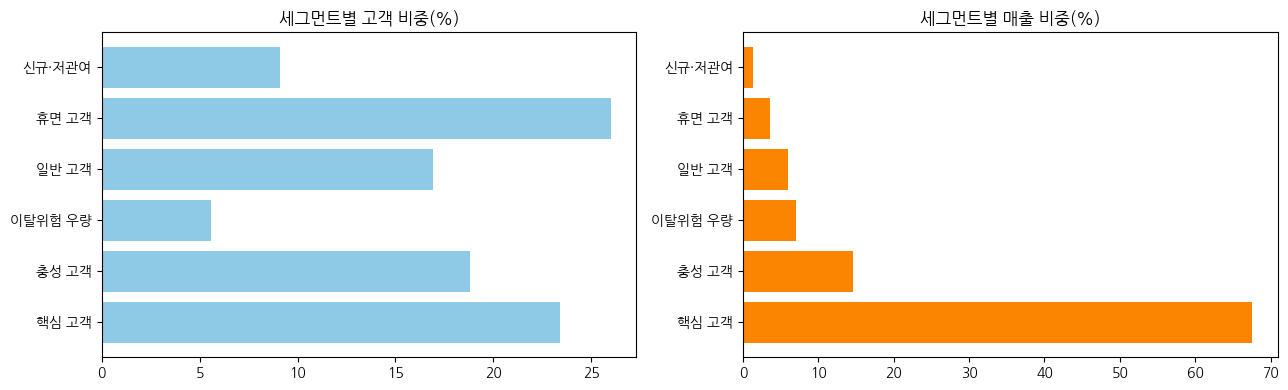

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].barh(seg["세그먼트"], seg["고객비중(%)"], color="#8ecae6"); ax[0].set_title("세그먼트별 고객 비중(%)")
ax[1].barh(seg["세그먼트"], seg["매출비중(%)"], color="#fb8500"); ax[1].set_title("세그먼트별 매출 비중(%)")
plt.tight_layout(); plt.show()